In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

resultado01.pgm: Diferentes: 251 pixels (12.3951% do total)
resultado01.pgm: Maior diferença: 7
resultado01.pgm: Primeiros pixels diferentes (linha, coluna):
[[ 0 28]
 [ 0 29]
 [ 0 30]
 [ 0 31]
 [ 0 32]
 [ 0 33]
 [ 0 34]
 [ 0 35]
 [ 0 36]
 [ 0 37]]


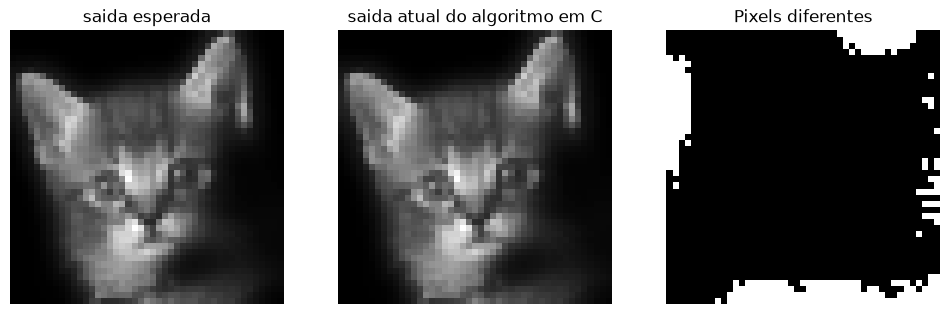

resultado03.pgm: Diferentes: 1067 pixels (52.6914% do total)
resultado03.pgm: Maior diferença: 7
resultado03.pgm: Primeiros pixels diferentes (linha, coluna):
[[ 0  6]
 [ 0  7]
 [ 0 10]
 [ 0 11]
 [ 0 12]
 [ 0 13]
 [ 0 14]
 [ 0 15]
 [ 0 16]
 [ 0 17]]


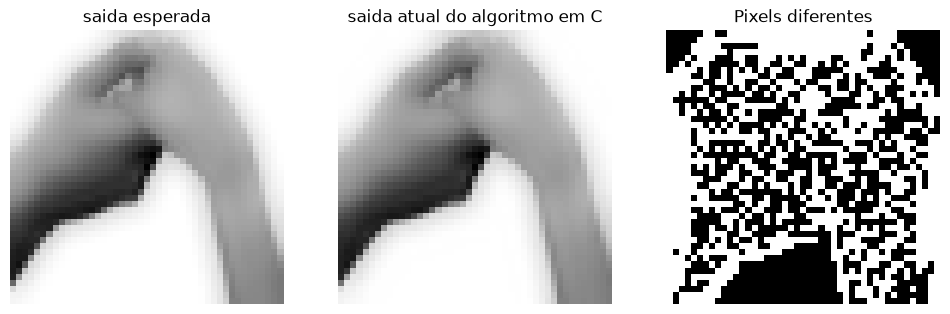

resultado02.pgm: Diferentes: 1159 pixels (57.2346% do total)
resultado02.pgm: Maior diferença: 8
resultado02.pgm: Primeiros pixels diferentes (linha, coluna):
[[0 0]
 [0 1]
 [0 2]
 [0 3]
 [0 4]
 [0 5]
 [0 6]
 [0 7]
 [0 8]
 [0 9]]


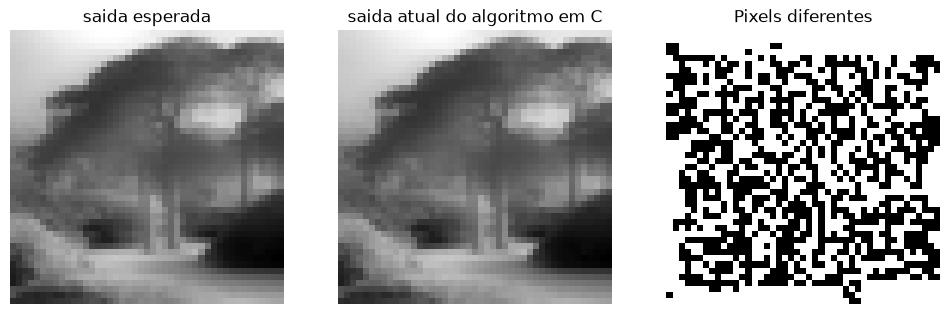

resultado07.pgm: Diferentes: 1200 pixels (59.2593% do total)
resultado07.pgm: Maior diferença: 10
resultado07.pgm: Primeiros pixels diferentes (linha, coluna):
[[ 0  0]
 [ 0  1]
 [ 0  2]
 [ 0  3]
 [ 0  4]
 [ 0  5]
 [ 0  9]
 [ 0 10]
 [ 0 11]
 [ 0 12]]


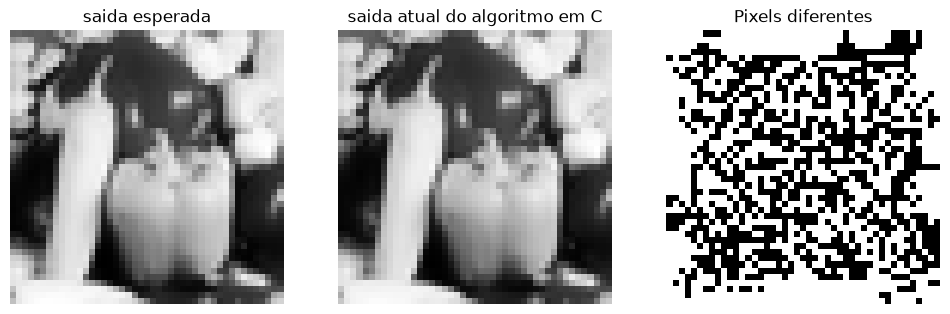

resultado08.pgm: Diferentes: 1053 pixels (52.0000% do total)
resultado08.pgm: Maior diferença: 12
resultado08.pgm: Primeiros pixels diferentes (linha, coluna):
[[ 0  0]
 [ 0  1]
 [ 0  2]
 [ 0  3]
 [ 0  5]
 [ 0  6]
 [ 0  7]
 [ 0  8]
 [ 0  9]
 [ 0 10]]


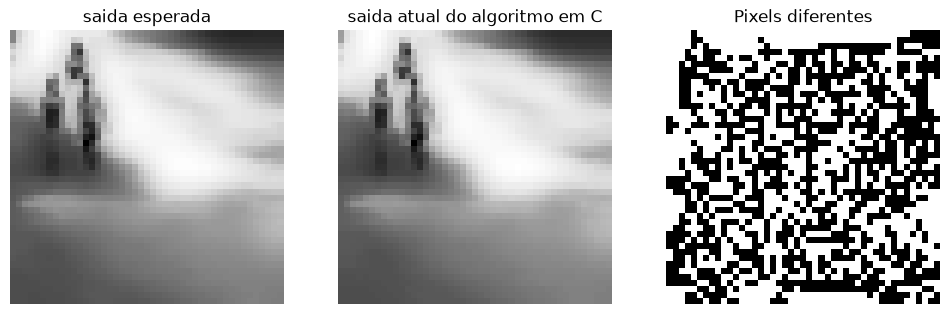

resultado10.pgm: Diferentes: 981 pixels (48.4444% do total)
resultado10.pgm: Maior diferença: 4
resultado10.pgm: Primeiros pixels diferentes (linha, coluna):
[[ 0  4]
 [ 1  4]
 [ 1 28]
 [ 1 29]
 [ 1 30]
 [ 1 31]
 [ 1 32]
 [ 1 33]
 [ 1 34]
 [ 1 35]]


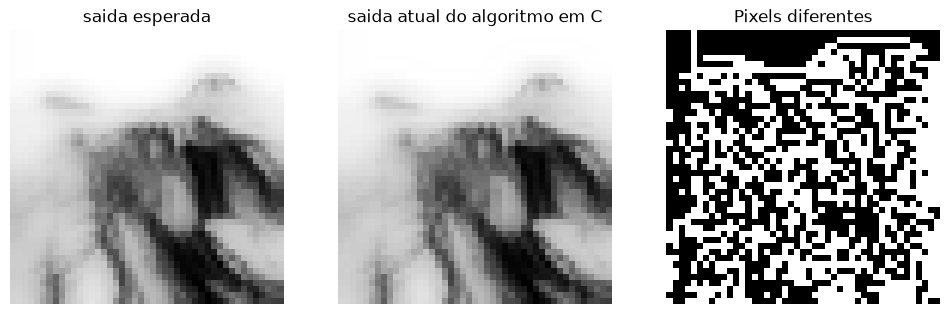

resultado06.pgm: Diferentes: 1232 pixels (60.8395% do total)
resultado06.pgm: Maior diferença: 5
resultado06.pgm: Primeiros pixels diferentes (linha, coluna):
[[ 0  0]
 [ 0  1]
 [ 0  4]
 [ 0  5]
 [ 0  6]
 [ 0  7]
 [ 0  8]
 [ 0  9]
 [ 0 10]
 [ 0 11]]


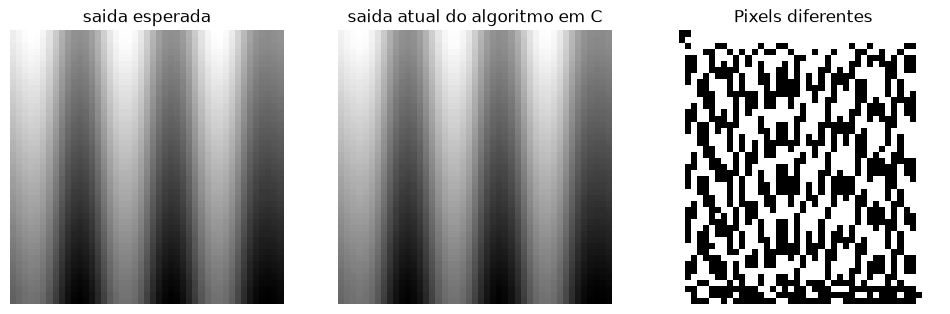

resultado09.pgm: Diferentes: 1180 pixels (58.2716% do total)
resultado09.pgm: Maior diferença: 6
resultado09.pgm: Primeiros pixels diferentes (linha, coluna):
[[0 0]
 [0 1]
 [0 2]
 [0 3]
 [0 4]
 [0 5]
 [0 6]
 [0 7]
 [0 8]
 [0 9]]


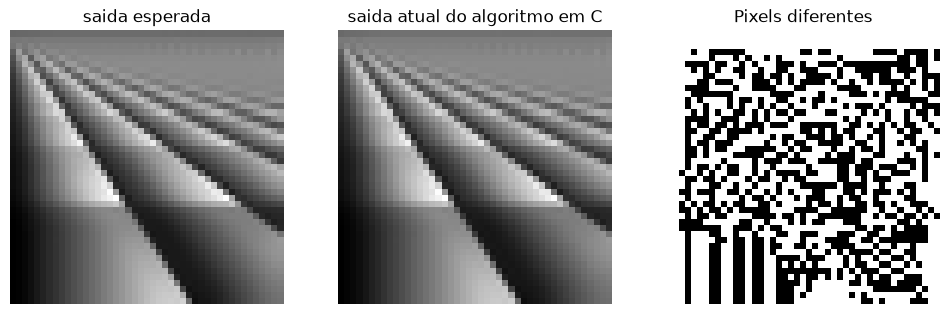

resultado04.pgm: Diferentes: 1140 pixels (56.2963% do total)
resultado04.pgm: Maior diferença: 5
resultado04.pgm: Primeiros pixels diferentes (linha, coluna):
[[ 0  0]
 [ 0  1]
 [ 0  3]
 [ 0  4]
 [ 0  5]
 [ 0  6]
 [ 0  7]
 [ 0  8]
 [ 0  9]
 [ 0 10]]


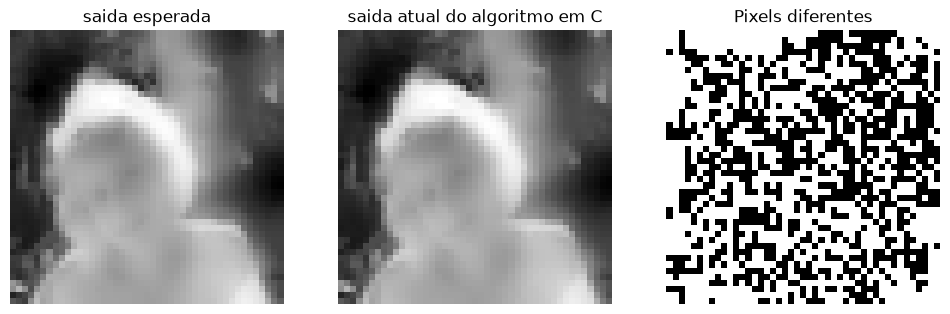

resultado05.pgm: Diferentes: 1033 pixels (51.0123% do total)
resultado05.pgm: Maior diferença: 5
resultado05.pgm: Primeiros pixels diferentes (linha, coluna):
[[ 0  2]
 [ 0  3]
 [ 0  4]
 [ 0  6]
 [ 0  7]
 [ 0  8]
 [ 0  9]
 [ 0 10]
 [ 0 11]
 [ 0 12]]


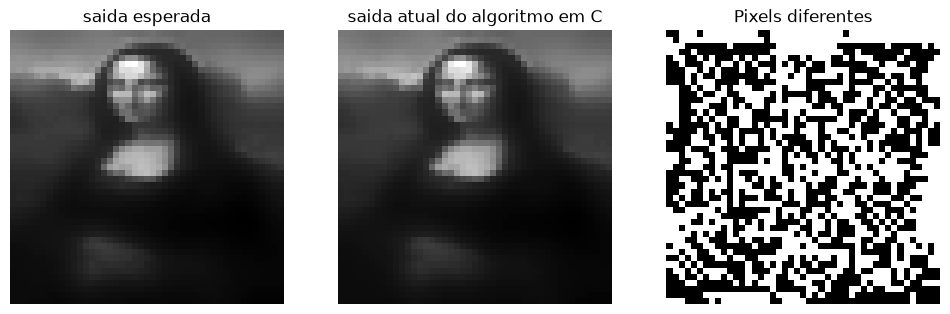

resultado11.pgm: Diferentes: 992 pixels (48.9877% do total)
resultado11.pgm: Maior diferença: 5
resultado11.pgm: Primeiros pixels diferentes (linha, coluna):
[[ 4 16]
 [ 4 17]
 [ 4 18]
 [ 4 19]
 [ 4 20]
 [ 4 21]
 [ 4 22]
 [ 4 23]
 [ 4 24]
 [ 4 25]]


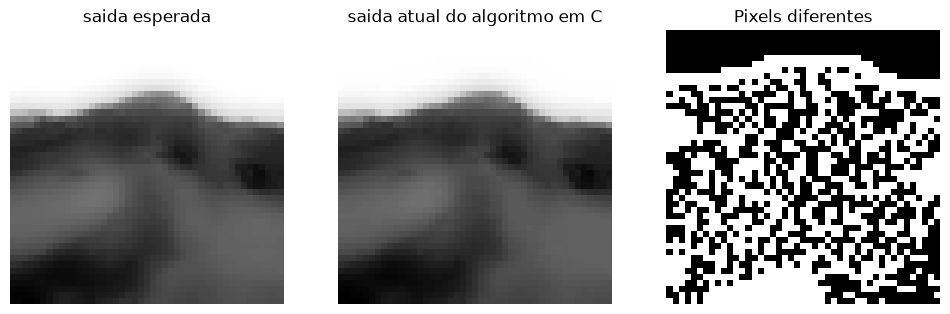

resultado12.pgm: Diferentes: 1129 pixels (55.7531% do total)
resultado12.pgm: Maior diferença: 4
resultado12.pgm: Primeiros pixels diferentes (linha, coluna):
[[ 0  3]
 [ 0  5]
 [ 0  7]
 [ 0  8]
 [ 0  9]
 [ 0 10]
 [ 0 12]
 [ 0 13]
 [ 0 14]
 [ 0 15]]


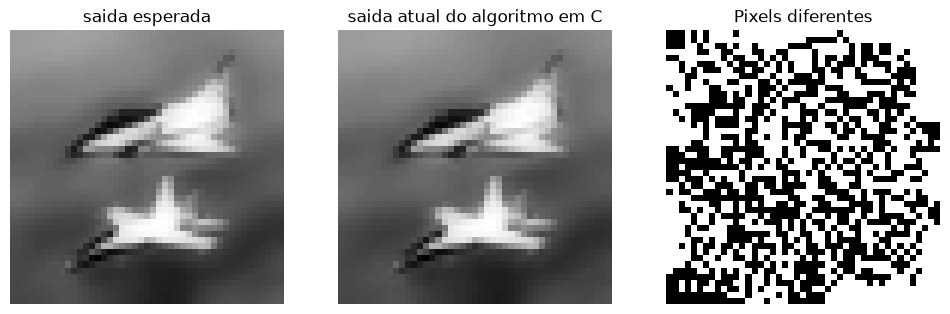

In [4]:
for filename in os.listdir("images_pgm_c_filtradas"):
    if filename.endswith(".pgm"):
        output_actual = cv2.imread(os.path.join("images_pgm_c_filtradas", filename), cv2.IMREAD_GRAYSCALE)
        output_expected = cv2.imread(os.path.join("images_pgm_py_filtradas_round", filename), cv2.IMREAD_GRAYSCALE)

        if output_expected.shape != output_actual.shape:
            print(f"{filename}: Diferentes: dimensões distintas")
        elif output_expected.dtype != output_actual.dtype:
            print(f"{filename}: Diferentes: tipos de dado distintos (ex.: 8 vs 16 bits)")
        elif np.array_equal(output_expected, output_actual):
            print(f"{filename}: As imagens são idênticas pixel a pixel")
        else:
            mask = output_expected != output_actual
            n_diff = mask.sum()
            print(f"{filename}: Diferentes: {n_diff} pixels ({100 * n_diff / mask.size:.4f}% do total)")

            # diferença absoluta em tipo maior, para evitar overflow do uint8
            diff = np.abs(output_expected.astype(np.int32) - output_actual.astype(np.int32))
            print(f"{filename}: Maior diferença:", diff.max())

            coords = np.argwhere(mask)
            print(f"{filename}: Primeiros pixels diferentes (linha, coluna):")
            print(coords[:10])

        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes[0].imshow(output_expected, cmap="gray"); axes[0].set_title("saida esperada")
        axes[1].imshow(output_actual, cmap="gray"); axes[1].set_title("saida atual do algoritmo em C")
        axes[2].imshow(mask, cmap="gray"); axes[2].set_title("Pixels diferentes")
        for ax in axes:
            ax.axis("off")
        plt.show()

# output_actual = cv2.imread("images_pgm_c_filtradas/resultado01.pgm", cv2.IMREAD_GRAYSCALE)
# output_actual = cv2.imread("images_pgm_c_filtradas/resultado01.pgm", cv2.IMREAD_GRAYSCALE)

# output_expected = cv2.imread("images_pgm_py_filtradas/resultado01.pgm", cv2.IMREAD_GRAYSCALE)

# if output_expected.shape != output_actual.shape:
#     print("Diferentes: dimensões distintas")
# elif output_expected.dtype != output_actual.dtype:
#     print("Diferentes: tipos de dado distintos (ex.: 8 vs 16 bits)")
# elif np.array_equal(output_expected, output_actual):
#     print("As imagens são idênticas pixel a pixel")
# else:
#     mask = output_expected != output_actual
#     n_diff = mask.sum()
#     print(f"Diferentes: {n_diff} pixels ({100 * n_diff / mask.size:.4f}% do total)")

#     # diferença absoluta em tipo maior, para evitar overflow do uint8
#     diff = np.abs(output_expected.astype(np.int32) - output_actual.astype(np.int32))
#     print("Maior diferença:", diff.max())

#     coords = np.argwhere(mask)
#     print("Primeiros pixels diferentes (linha, coluna):")
#     print(coords[:10])


# fig, axs = plt.subplots(1, 3, figsize=(12, 4))
# axs[0].imshow(output_expected, cmap="gray"); axs[0].set_title("saida esperada")
# axs[1].imshow(output_actual, cmap="gray"); axs[1].set_title("saida atual do algoritmo em C")
# axs[2].imshow(mask, cmap="gray"); axs[2].set_title("Pixels diferentes")
# for ax in axs:
#     ax.axis("off")
# plt.show()